# Урок 3.3. Аддитивные модели и пошаговое построение

**Интерактивная версия:** `lessons/lesson_3_3/web/index.html`

1. FSAM с квадратичными потерями = обучение на остатках.
2. FSAM с экспоненциальными потерями = AdaBoost (численная проверка вывода).
3. Потери через отступ.
4. Экспоненциальные против логистических при шуме в метках.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from gbcourse import datasets, AdaBoost, RegressionTree, GBRegressor, Mulberry32
from gbcourse.plotting import use_course_style

use_course_style()

## 1. FSAM с L2: каждое слагаемое подгоняется к остаткам

In [2]:
X, y = datasets.regression_1d(kind="wave", n=80, noise=0.3, seed=2)
F = np.full_like(y, y.mean())
for _ in range(20):
    r = y - F                                       # остатки
    h = RegressionTree(max_depth=2).fit(X, -r)      # дерево на остатках (g = −r)
    F = F + h.predict(X)                            # β = 1: для L2 оптимальный множитель уже «в листьях»
gb = GBRegressor(n_estimators=20, learning_rate=1.0, max_depth=2).fit(X, y)
print("FSAM(L2) совпадает с бустингом на остатках (ν = 1):", np.allclose(F, gb.predict(X)))

FSAM(L2) совпадает с бустингом на остатках (ν = 1): True


## 2. FSAM с экспоненциальными потерями = AdaBoost

Проверим численно: для первого пня AdaBoost найдём $\beta$, минимизирующее
$\sum_i w_i e^{-\beta y_i b(x_i)}$, перебором — и сравним с $\tfrac12\ln\frac{1-\varepsilon}{\varepsilon}$.

In [3]:
Xc, yc = datasets.classification_2d(kind="moons", n=200, noise=0.25, seed=33)
ys = np.where(yc > 0, 1, -1)
ada = AdaBoost(n_estimators=3).fit(Xc, yc)
b = np.where(ada.trees_[0].predict(Xc) >= 0, 1, -1)
w = np.full(len(ys), 1 / len(ys))
betas = np.linspace(0.01, 2, 20000)
loss = [(w * np.exp(-bt * ys * b)).sum() for bt in betas]
print(f"β перебором: {betas[int(np.argmin(loss))]:.4f};  α AdaBoost: {ada.alphas_[0]:.4f}")

β перебором: 0.7415;  α AdaBoost: 0.7414


## 3. Потери через отступ

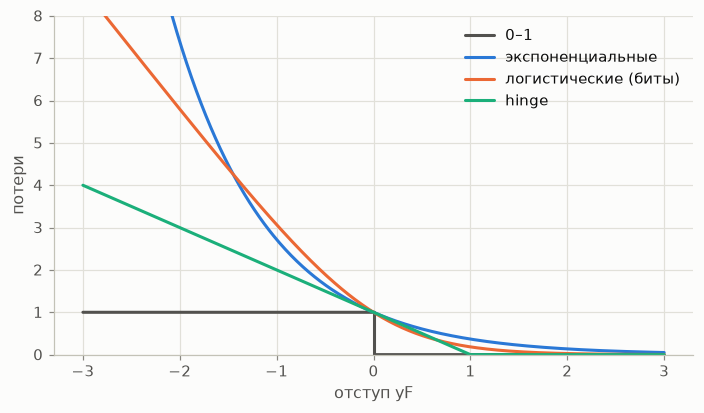

In [4]:
m = np.linspace(-3, 3, 601)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.step(m, (m <= 0).astype(float), where="post", color="#52514e", label="0–1")
ax.plot(m, np.exp(-m), label="экспоненциальные")
ax.plot(m, np.log1p(np.exp(-2 * m)) / np.log(2), label="логистические (биты)")
ax.plot(m, np.maximum(0, 1 - m), label="hinge")
ax.set(ylim=(0, 8), xlabel="отступ yF", ylabel="потери")
ax.legend()
plt.show()

## 4. Шум в метках: экспоненциальные против логистических

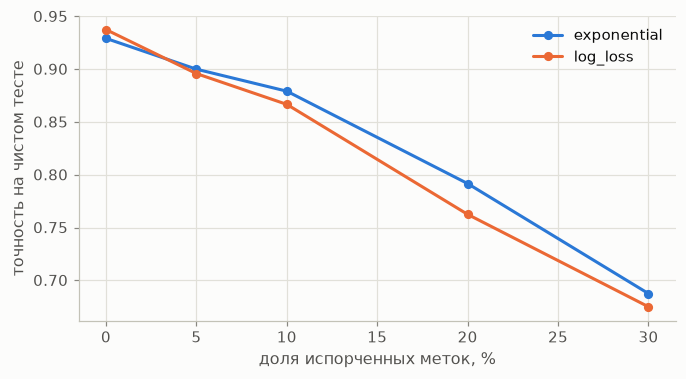

exponential [0.929 0.9   0.879 0.792 0.688]
log_loss [0.938 0.896 0.867 0.762 0.675]


In [5]:
X, y = datasets.classification_2d(kind="moons", n=600, noise=0.25, seed=33)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X, y, test_size=0.4, seed=0)
fracs = [0.0, 0.05, 0.1, 0.2, 0.3]
res = {"exponential": [], "log_loss": []}
for frac in fracs:
    rng = Mulberry32(1)
    flip = np.array([rng.random() < frac for _ in y_tr])
    yy = np.where(flip, 1 - y_tr, y_tr)
    for loss_name in res:
        mdl = GradientBoostingClassifier(loss=loss_name, n_estimators=300, learning_rate=0.1, max_depth=2).fit(X_tr, yy)
        res[loss_name].append(mdl.score(X_te, y_te))
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, vals in res.items():
    ax.plot(np.array(fracs) * 100, vals, marker="o", label=name)
ax.set(xlabel="доля испорченных меток, %", ylabel="точность на чистом тесте")
ax.legend()
plt.show()
for name, vals in res.items():
    print(name, np.round(vals, 3))

На этих данных с ν = 0.1 и деревьями глубины 2 разница между потерями невелика — теоретическая
«взрывоопасность» экспоненциальных потерь сдерживается маленьким шагом и ограниченным числом
деревьев. Опаснее всего она в классическом AdaBoost с полным шагом (урок 3.2). Решающие доводы в
пользу log-loss в градиентном бустинге — корректные вероятности и связь с правдоподобием (урок 6.1).

## Упражнения

1. Выведите оптимальное β для шага FSAM с экспоненциальными потерями (приравняйте производную нулю).
2. Реализуйте FSAM с экспоненциальными потерями «в лоб»: на каждом шаге перебирайте пни и β одновременно. Совпадает ли результат с AdaBoost?
3. Докажите, что минимум $\mathbb{E}[e^{-yF}\mid x]$ достигается при $F = \tfrac12\ln\frac{p}{1-p}$.

Решения: `python lessons/lesson_3_3/exercises/solutions.py`.